In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
import sys
if '../src' not in sys.path:
    sys.path.append('../src')
from utilidades import *

In [2]:
df = pd.read_csv('../input/updated_students_performance_dataset.csv')


In [3]:
def categorizar(valor):
    if valor.startswith('A'):
        return 'A'
    elif valor.startswith('B'):
        return 'B'
    elif valor.startswith('C'):
        return 'C'
    elif valor.startswith('D'):
        return 'D'
    elif valor == 'Fail':
        return 'Fail'
    else:
        return 'Otros' 

df['GRADE'] = df['GRADE'].apply(categorizar)

In [4]:
X = df.iloc[:,[1,2,3,4,5,7,11,12,17,20,22,23,25,26,29]]
Y = df.iloc[:,[32]]

In [5]:
encoder = OneHotEncoder(sparse=False)
X_encoded = encoder.fit_transform(X)
model = LogisticRegression(multi_class='multinomial',solver='lbfgs',max_iter=1000)
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded,Y,test_size=0.30)

c:\Users\bcriv\miniconda3\envs\redes_sociales\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [6]:

model = entrenamiento_modelo(model,X_train,Y_train)

c:\Users\bcriv\miniconda3\envs\redes_sociales\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [7]:
from utilidades import prediccion_modelo

Y_pred = prediccion_modelo(model,X_test)

In [8]:
Y_pred

array(['D', 'D', 'C', 'B', 'C', 'D', 'A', 'D', 'A', 'D', 'C', 'B', 'D',
       'D', 'D', 'D', 'B', 'B', 'B', 'B', 'D', 'C', 'D', 'B', 'B', 'B',
       'B', 'D', 'C', 'D', 'B', 'B', 'C', 'C', 'D', 'B', 'D', 'D', 'D',
       'B', 'A', 'B', 'B', 'D'], dtype=object)

In [9]:
from utilidades import evaluacion_modelo

ev = evaluacion_modelo(Y_test,Y_pred)

class_report:               precision    recall  f1-score   support

           A       1.00      0.43      0.60         7
           B       0.31      0.71      0.43         7
           C       0.71      0.45      0.56        11
           D       0.67      0.75      0.71        16
        Fail       0.00      0.00      0.00         3

    accuracy                           0.57        44
   macro avg       0.54      0.47      0.46        44
weighted avg       0.63      0.57      0.56        44



c:\Users\bcriv\miniconda3\envs\redes_sociales\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\bcriv\miniconda3\envs\redes_sociales\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\bcriv\miniconda3\envs\redes_sociales\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(r

In [10]:
feature_names = encoder.get_feature_names_out()

In [11]:
y_unique=list(Y['GRADE'].unique())

In [12]:
sorted(y_unique)

['A', 'B', 'C', 'D', 'Fail']

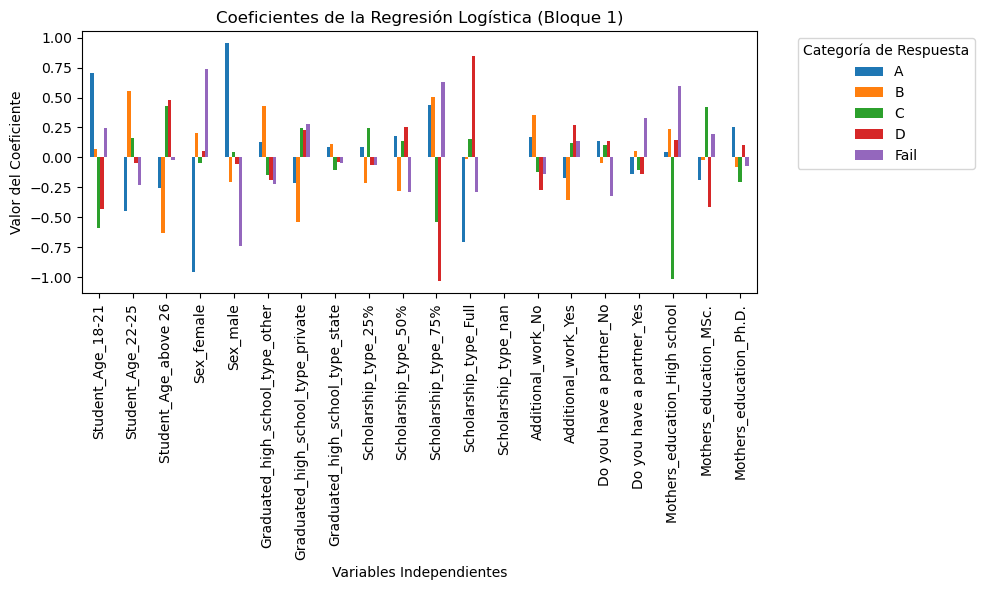

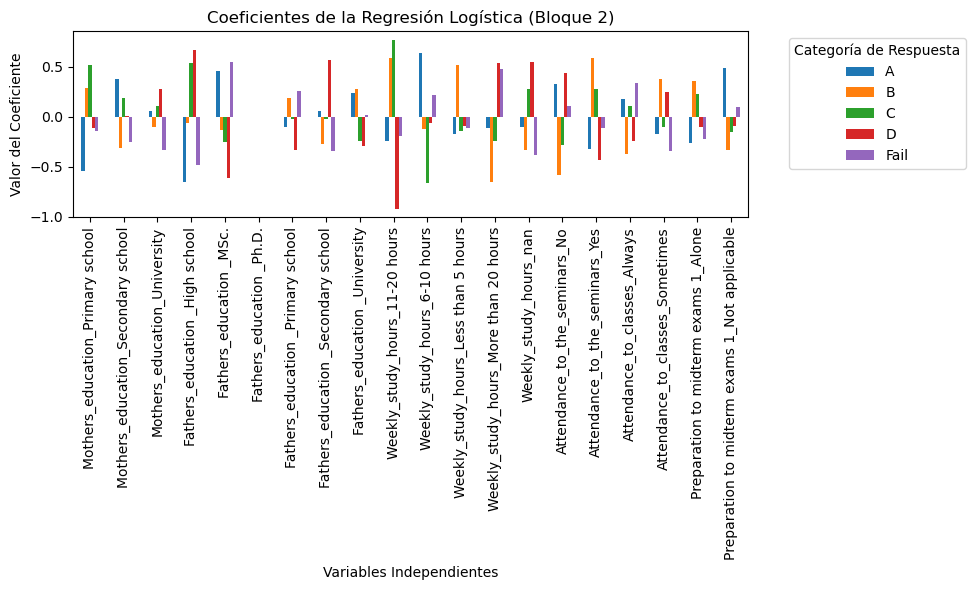

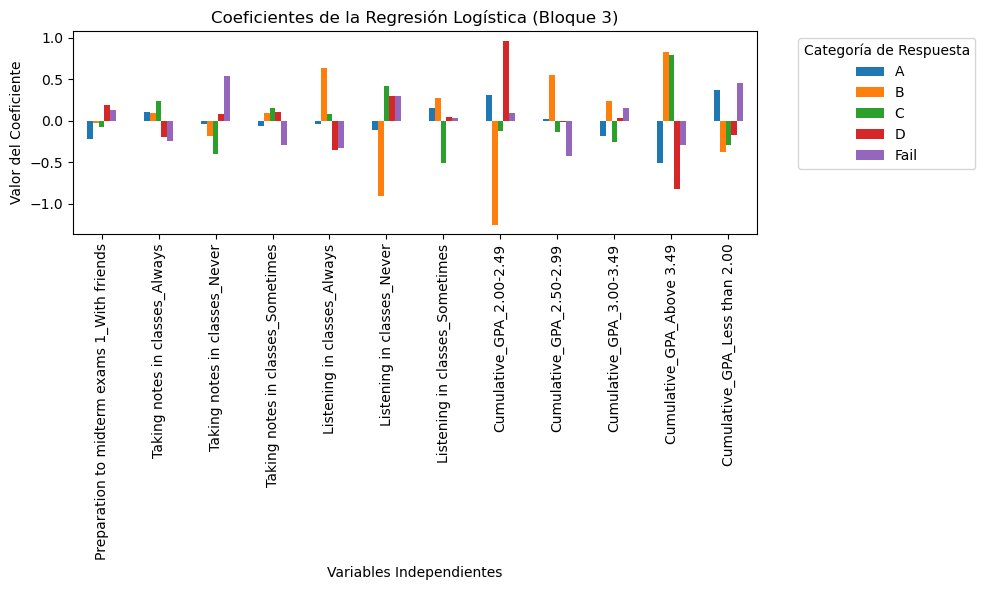

In [13]:
plot_coef_multiclass_logreg(model,feature_names,20)

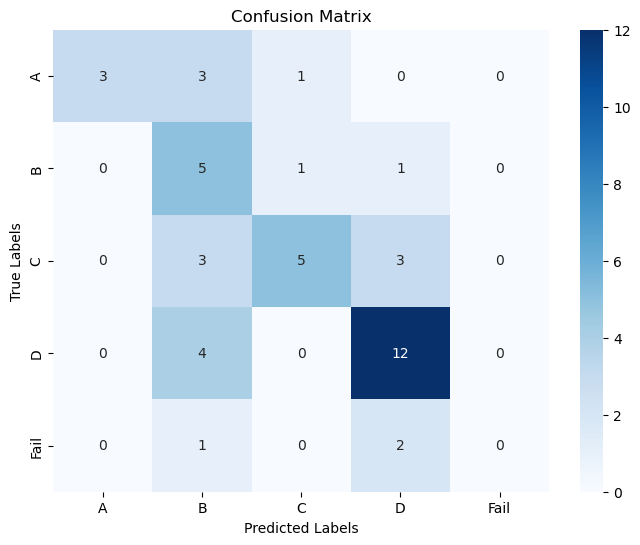

In [14]:
plot_confusion_matrix(Y_test,Y_pred,sorted(y_unique))

In [15]:
Y_test.value_counts()

GRADE
D        16
C        11
A         7
B         7
Fail      3
Name: count, dtype: int64

In [16]:
def get_coefficients_table(model, feature_names, class_names):
    """
    Función para crear una tabla con los coeficientes del modelo de regresión logística multinomial.
    
    Parameters:
    model: Modelo de regresión logística multinomial entrenado.
    feature_names: Lista de nombres de las variables.
    class_names: Lista de nombres de las clases objetivo.
    
    Returns:
    Una tabla (DataFrame) con los coeficientes de cada variable para cada clase.
    """
    # Obtener los coeficientes del modelo
    coefficients = model.coef_
    
    # Crear un DataFrame con los coeficientes
    coeff_df = pd.DataFrame(coefficients, columns=feature_names, index=class_names).T
    
    # Ordenar las variables por la magnitud de los coeficientes (opcional)
    coeff_df['mean_absolute_coeff'] = coeff_df.abs().mean(axis=1)
    coeff_df = coeff_df.sort_values(by='mean_absolute_coeff', ascending=False)
    
    return coeff_df

In [17]:
get_coefficients_table(model,feature_names,y_unique)

,D,B,Fail,C,A,mean_absolute_coeff
Cumulative_GPA_Above 3.49,-0.513551,0.828055,0.790921,-0.818817,-0.286608,0.647590
Scholarship_type_75%,0.438303,0.502834,-0.537208,-1.034989,0.631060,0.628879
Cumulative_GPA_2.00-2.49,0.307721,-1.251562,-0.120029,0.967763,0.096107,0.548637
Weekly_study_hours_11-20 hours,-0.245481,0.587771,0.767372,-0.919056,-0.190606,0.542057
Fathers_education _High school,-0.652101,-0.060496,0.536916,0.661668,-0.485987,0.479433
Student_Age_18-21,0.701394,0.070774,-0.589968,-0.431506,0.249306,0.408590
Listening in classes_Never,-0.110354,-0.907109,0.422694,0.298485,0.296284,0.406985
Mothers_education_High school,0.041198,0.235220,-1.016548,0.141974,0.598156,0.406619
Weekly_study_hours_More than 20 hours,-0.108596,-0.650354,-0.245112,0.532829,0.471234,0.401625
Fathers_education _MSc.,0.454956,-0.131717,-0.254774,-0.614179,0.545714,0.400268


In [18]:
ev[0]

0.5681818181818182